# Tutorial 10a — ISO 10110 Fabrication Drawings

This tutorial demonstrates how to generate ISO 10110-compliant fabrication drawings
directly from an optiland lens design.

## What is ISO 10110?

ISO 10110 is the international standard for optical element drawings used in manufacturing.
It defines a coding system that annotates lens drawings with:

| Code | ISO Part | Description |
|------|----------|-------------|
| `0/` | 10110-2  | Stress birefringence (nm/cm) |
| `1/` | 10110-3  | Bubbles and inclusions |
| `2/` | 10110-4  | Inhomogeneity and striae |
| `3/` | 10110-5  | Surface form error (waves P-V) |
| `4/` | 10110-6  | Centration tolerance (arcmin) |
| `5/` | 10110-7  | Surface imperfections (scratch-dig) |

## Architecture

The `optiland.iso10110` module works as a **fabrication annotation layer** on top
of the optical model:

```
Optic (geometry only)
    ↓
DrawingSpec (geometry + tolerances)
    ↓
ISO10110Report → DXF + PDF
```

- **Surface-level specs** (`3/`, `4/`, `5/`): annotated per surface — filled in by the *optical designer*
- **Element-level specs** (`0/`, `1/`, `2/`): bulk glass quality — typically negotiated with the *glass supplier / optician*

Unspecified fields render as `—` so drawings can be issued incrementally.

## 1. Define the Lens System

We design a **5-element photographic objective** (f ≈ 50 mm, f/4) with one cemented doublet.
The layout is inspired by a modified Tessar / Heliar type:

```
  E1 (singlet)   E2 (singlet)   E3 (cemented doublet)   E4 (singlet)   E5 (singlet)
  ──┬──          ──┬──          ──┬───┬──                ──┬──          ──┬──
    │               │              │   │ cement              │               │
  ──┴──          ──┴──          ──┴───┴──                ──┴──          ──┴──
         [STOP between E2 and E3]
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from optiland import optic
import optiland.backend as be

lens = optic.Optic(name='5-Element Photographic Objective')

# ── Object ──────────────────────────────────────────────────────────────────
lens.surfaces.add(index=0, radius=be.inf, thickness=be.inf)

# ── Element 1: biconvex singlet  N-BK7 ─────────────────────────────────────
lens.surfaces.add(index=1, radius=22.0,   thickness=6.0,  material='N-BK7')
lens.surfaces.add(index=2, radius=-95.0,  thickness=2.5)

# ── Element 2: negative meniscus  N-SF2 ────────────────────────────────────
lens.surfaces.add(index=3, radius=-28.0,  thickness=2.0,  material='N-SF2')
lens.surfaces.add(index=4, radius=26.0,   thickness=8.5,  is_stop=True)

# ── Element 3: cemented doublet  N-BAK1 / N-SF5 ────────────────────────────
lens.surfaces.add(index=5, radius=58.0,   thickness=5.5,  material='N-BAK1')
lens.surfaces.add(index=6, radius=-17.0,  thickness=2.5,  material='N-SF5')   # cement
lens.surfaces.add(index=7, radius=-75.0,  thickness=1.5)

# ── Element 4: biconvex singlet  N-SSK5 ────────────────────────────────────
lens.surfaces.add(index=8, radius=28.0,   thickness=5.0,  material='N-SSK5')
lens.surfaces.add(index=9, radius=-80.0,  thickness=1.5)

# ── Element 5: positive singlet  N-LAK22 ───────────────────────────────────
lens.surfaces.add(index=10, radius=40.0,  thickness=4.5,  material='N-LAK22')
lens.surfaces.add(index=11, radius=-48.0, thickness=0.0)  # BFD set by image_solve

# ── Image ────────────────────────────────────────────────────────────────────
lens.surfaces.add(index=12)

# ── System aperture and fields ───────────────────────────────────────────────
lens.set_aperture(aperture_type='EPD', value=14.0)
lens.fields.set_type('angle')
lens.fields.add(y=0.0)
lens.fields.add(y=7.0)
lens.fields.add(y=10.0)

lens.wavelengths.add(value=0.4861)
lens.wavelengths.add(value=0.5876, is_primary=True)
lens.wavelengths.add(value=0.6563)

lens.updater.image_solve()
print(lens.surfaces.surfaces[11].thickness)
lens.updater.update_paraxial()

print('Total track: ', lens.total_track, 'mm')
print('Surfaces:    ', lens.surfaces.num_surfaces)

13.381058440952472
Total track:  52.88105844095247 mm
Surfaces:     13


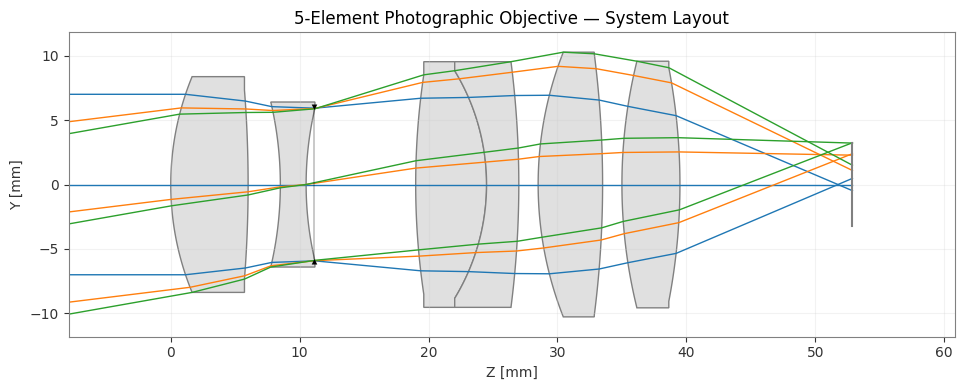

In [2]:
# Trace rays to populate semi-apertures on all surfaces
lens.trace(Hx=0, Hy=0, wavelength=0.5876, num_rays=100)

# Quick system overview
lens.draw(num_rays=3, figsize=(12, 4))
plt.title('5-Element Photographic Objective — System Layout')
plt.tight_layout()
plt.show()

In [3]:
# Print the lens prescription
lens.info()

╒════╤═════════════════╤═══════════╤══════════╤═════════════╤════════════╤═════════╤═════════════════╕
│    │ Type            │ Comment   │   Radius │   Thickness │ Material   │   Conic │   Semi-aperture │
╞════╪═════════════════╪═══════════╪══════════╪═════════════╪════════════╪═════════╪═════════════════╡
│  0 │ Planar          │           │      inf │    inf      │ Air        │       0 │         8.66057 │
│  1 │ Standard        │           │       22 │      6      │ N-BK7      │       0 │         8.66057 │
│  2 │ Standard        │           │      -95 │      2.5    │ Air        │       0 │         7.15831 │
│  3 │ Standard        │           │      -28 │      2      │ N-SF2      │       0 │         6.11153 │
│  4 │ Stop - Standard │           │       26 │      8.5    │ Air        │       0 │         5.77489 │
│  5 │ Standard        │           │       58 │      5.5    │ N-BAK1     │       0 │         8.27375 │
│  6 │ Standard        │           │      -17 │      2.5    │ N-SF5      

## 2. Identify Lens Elements

`identify_elements()` walks the surface sequence and groups consecutive glass-bounded
surfaces into `LensElement` objects.  It recognises cemented doublets automatically.

In [4]:
from optiland.iso10110 import identify_elements

elements = identify_elements(lens)

print(f'Found {len(elements)} elements:\n')
for i, e in enumerate(elements):
    mats = [m.name if hasattr(m, 'name') else m.__class__.__name__
            for m in e.glass_materials]
    sa_vals = [f'{e.semi_aperture(j, lens):.2f}' for j in range(len(e.surfaces))]
    ct = e.center_thickness(lens)
    print(f'  Element {i+1}:  surfaces {e.surface_indices}  '
          f'glass={mats}  CT={ct:.2f} mm  '
          f'{"cemented doublet" if e.is_cemented else "singlet"}')

Found 5 elements:

  Element 1:  surfaces [1, 2]  glass=['N-BK7']  CT=6.00 mm  singlet
  Element 2:  surfaces [3, 4]  glass=['N-SF2']  CT=2.00 mm  singlet
  Element 3:  surfaces [5, 6, 7]  glass=['N-BAK1', 'N-SF5']  CT=8.00 mm  cemented doublet
  Element 4:  surfaces [8, 9]  glass=['N-SSK5']  CT=5.00 mm  singlet
  Element 5:  surfaces [10, 11]  glass=['N-LAK22']  CT=4.50 mm  singlet


## 3. Build the Drawing Specification

### 3.1 Surface-level tolerances  (designer fills these in)

Based on a tolerancing analysis (not shown here), we assign:
- `3/` Surface form error in waves P-V at 633 nm
- `4/` Centration tolerance in arcmin
- `5/` Surface imperfection in ISO dimensional notation

In [5]:
from optiland.iso10110 import DrawingSpec

spec = DrawingSpec(lens, project_name='5-Element Photographic Objective')

# ── Element 1 surfaces ──────────────────────────────────────────────────────
spec.set_surface(1,  irregularity=0.5, rotationally_symmetric=0.25,
                     centration=0.5,  imperfections='2x0.04')
spec.set_surface(2,  irregularity=1.0, centration=0.5,  imperfections='2x0.063')

# ── Element 2 surfaces ──────────────────────────────────────────────────────
spec.set_surface(3,  irregularity=0.5, centration=1.0,  imperfections='2x0.04')
spec.set_surface(4,  irregularity=0.5, centration=1.0,  imperfections='2x0.04')

# ── Element 3 (cemented doublet) surfaces ───────────────────────────────────
spec.set_surface(5,  irregularity=0.5, centration=0.5,  imperfections='2x0.04')
spec.set_surface(6,  irregularity=0.25, centration=0.5, imperfections='5x0.016'  # cement: tighter
                 )
spec.set_surface(7,  irregularity=0.5, centration=0.5,  imperfections='2x0.04')

# ── Element 4 surfaces ──────────────────────────────────────────────────────
spec.set_surface(8,  irregularity=0.5, centration=0.5,  imperfections='2x0.063')
spec.set_surface(9,  irregularity=1.0, centration=0.5,  imperfections='2x0.063')

# ── Element 5 surfaces ──────────────────────────────────────────────────────
spec.set_surface(10, irregularity=0.5, centration=0.5,  imperfections='2x0.04')
spec.set_surface(11, irregularity=0.5, centration=0.5,  imperfections='2x0.04')

print('Surface specs set.')

Surface specs set.


### 3.2 Element-level glass quality  (optician / procurement fills these in)

Glass quality codes are bulk material properties.  These are either specified
from the glass manufacturer's data sheet or negotiated with the supplier.
Unspecified fields will appear as `—` in the drawing.

In [6]:
# Element 0 → E1 (N-BK7 singlet)
spec.set_element(0,
    birefringence=10,
    bubbles='1x0.16',
    homogeneity_grade=2,
    striae_grade='A',
)
spec.set_title(0,
    part_number='OPT-001',
    drawn_by='B. Lutzer',
    approved_by='K. Harrison',
    revision='A',
)

# Element 1 → E2 (N-SF2 negative singlet)
spec.set_element(1,
    birefringence=10,
    bubbles='1x0.16',
    homogeneity_grade=2,
    striae_grade='B',
)
spec.set_title(1,
    part_number='OPT-002',
    drawn_by='B. Lutzer',
    approved_by='K. Harrison',
)

# Element 2 → E3 (cemented doublet N-BAK1 / N-SF5)
spec.set_element(2,
    birefringence=6,          # tighter: cemented optics are stress-sensitive
    bubbles='1x0.10',
    homogeneity_grade=2,
    striae_grade='A',
)
spec.set_title(2,
    part_number='OPT-003',
    drawn_by='B. Lutzer',
    approved_by='K. Harrison',
    notes='Cement with NOA-61 or equivalent UV adhesive.',
)

# Element 3 → E4 (N-SSK5)
spec.set_element(3,
    birefringence=10,
    bubbles='1x0.16',
    homogeneity_grade=3,
    striae_grade='B',
)
spec.set_title(3,
    part_number='OPT-004',
    drawn_by='B. Lutzer',
)

# Element 4 → E5 (N-LAK22)
spec.set_element(4,
    birefringence=10,
    bubbles='1x0.16',
    homogeneity_grade=2,
    striae_grade='A',
)
spec.set_title(4,
    part_number='OPT-005',
    drawn_by='B. Lutzer',
)

print('DrawingSpec:', spec)

DrawingSpec: DrawingSpec(5 elements, 11 surface specs, 5 element specs)


### 3.3 Save the spec to YAML (hand-off to optician)

The spec can be persisted and reloaded independently of the optic, enabling an
iterative workflow where the optical designer and the manufacturing team collaborate
asynchronously.

In [7]:
spec.save_yaml('photographic_lens_spec.yaml')
print('Spec saved to photographic_lens_spec.yaml')

# Round-trip verification
spec2 = DrawingSpec.load_yaml('photographic_lens_spec.yaml', lens)
print('Reloaded:', spec2)
print('E0 part number:', spec2.get_element_spec(0).part_number)
print('S1 form error: ', spec2.get_surface_spec(1).fmt_form_error())

Spec saved to photographic_lens_spec.yaml
Reloaded: DrawingSpec(5 elements, 11 surface specs, 5 element specs)
E0 part number: OPT-001
S1 form error:  3/ (0.5/0.25); λ=546.1 nm


## 4. Generate the Drawings

`ISO10110Report` iterates over all elements and generates one DXF drawing per element.
The drawings are rendered inline using ezdxf's matplotlib backend.

In [8]:
from optiland.iso10110 import ISO10110Report

report = ISO10110Report(spec)
report.generate()
print(f'Generated {len(report)} element drawings')

Generated 5 element drawings


### 4.1 Preview — Element 1 (N-BK7 biconvex singlet)

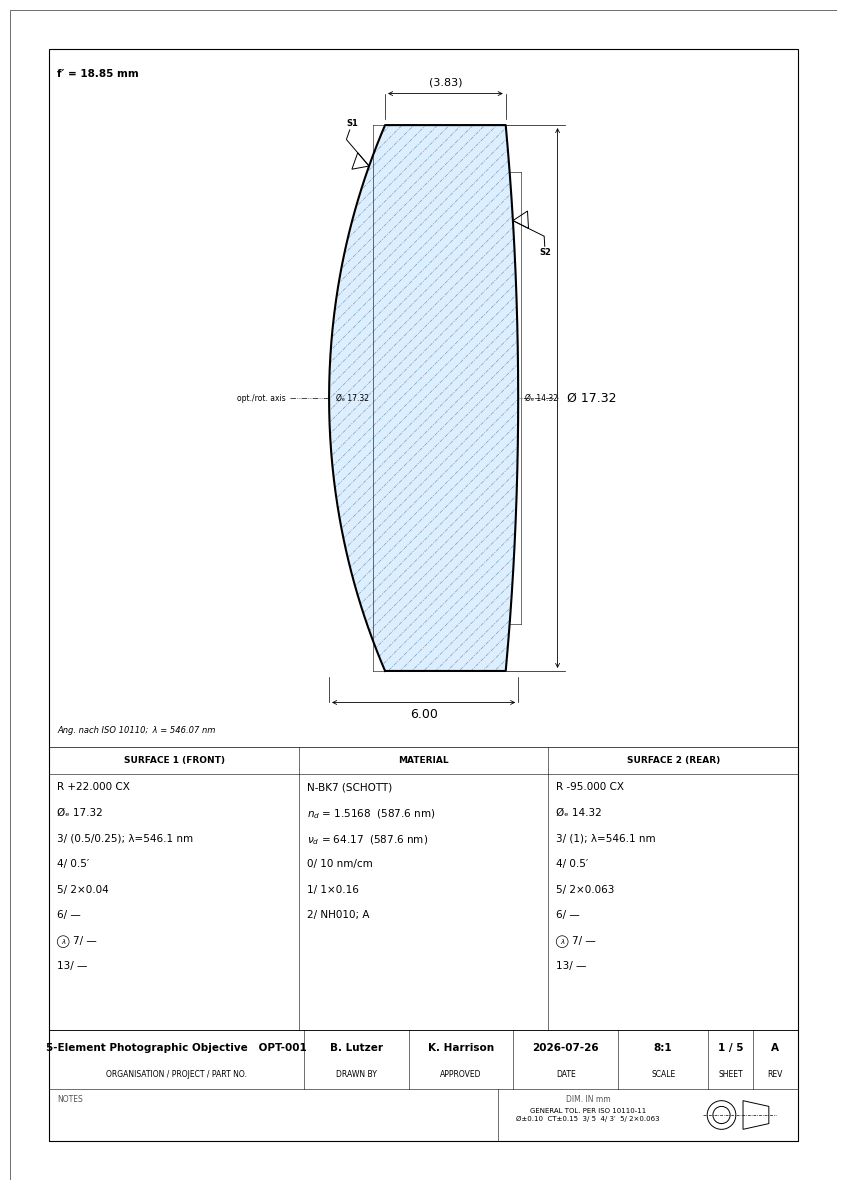

In [9]:
report.show(element_index=0, figsize=(16.5, 11.7))

### 4.2 Preview — Element 2 (N-SF2 negative singlet)

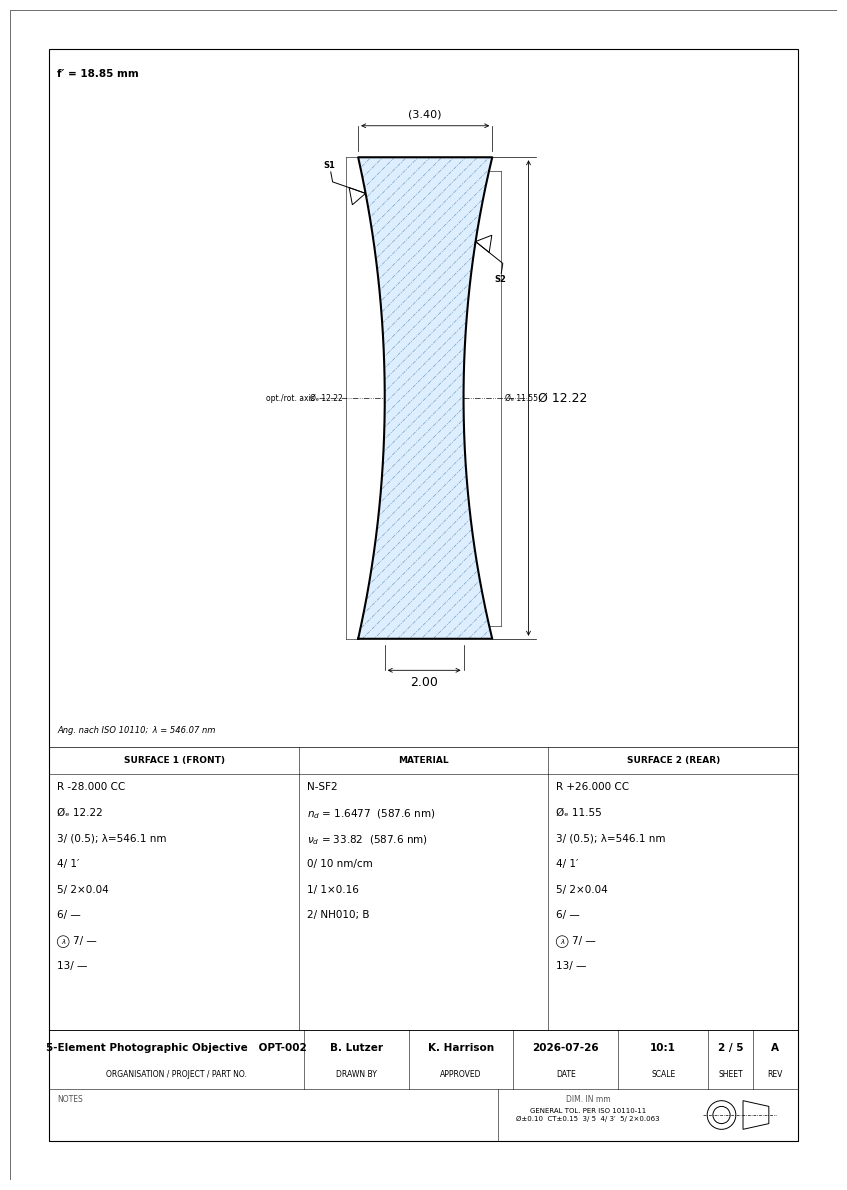

In [10]:
report.show(element_index=1, figsize=(16.5, 11.7))

### 4.3 Preview — Element 3 (cemented doublet N-BAK1 / N-SF5)

The cement interface is drawn as a thin solid line inside the element outline.
Component thicknesses `t1` and `t2` are dimensioned above the outline.

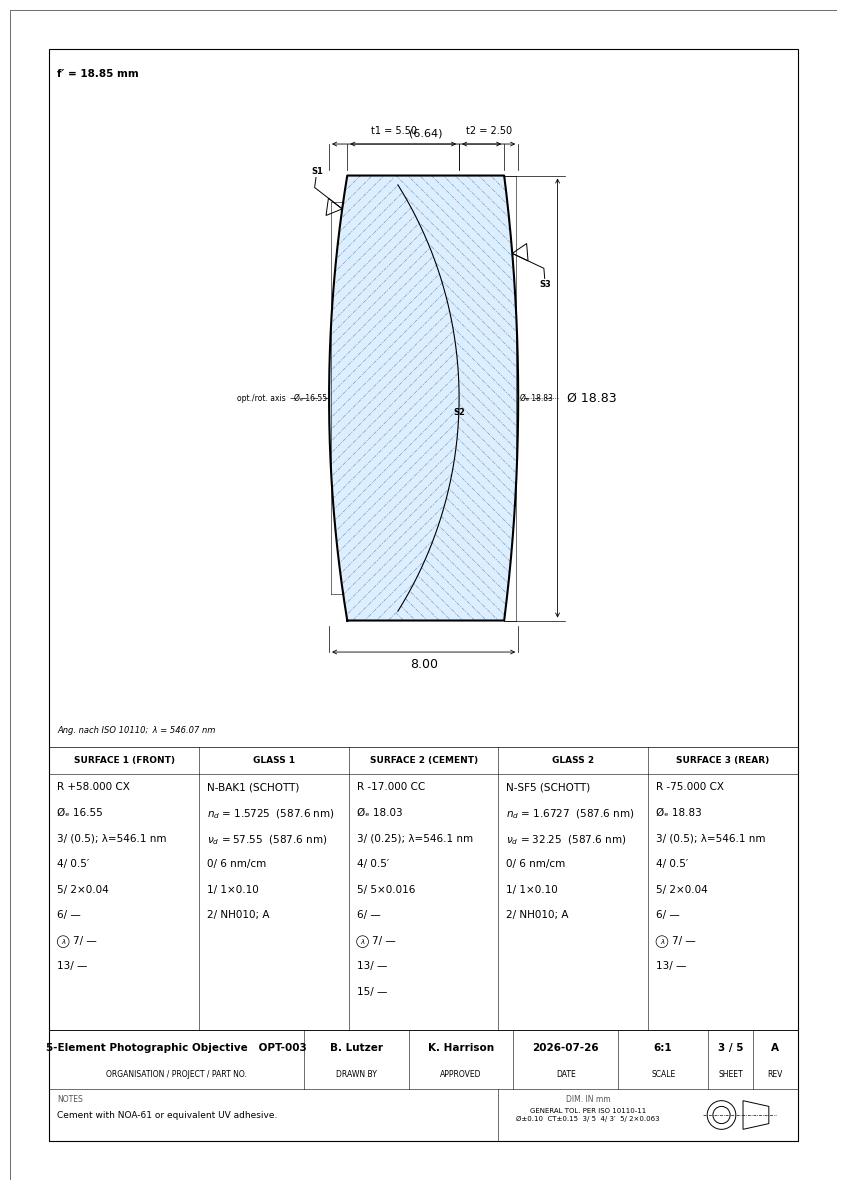

In [11]:
report.show(element_index=2, figsize=(16.5, 11.7))

### 4.4 Preview — Elements 4 and 5

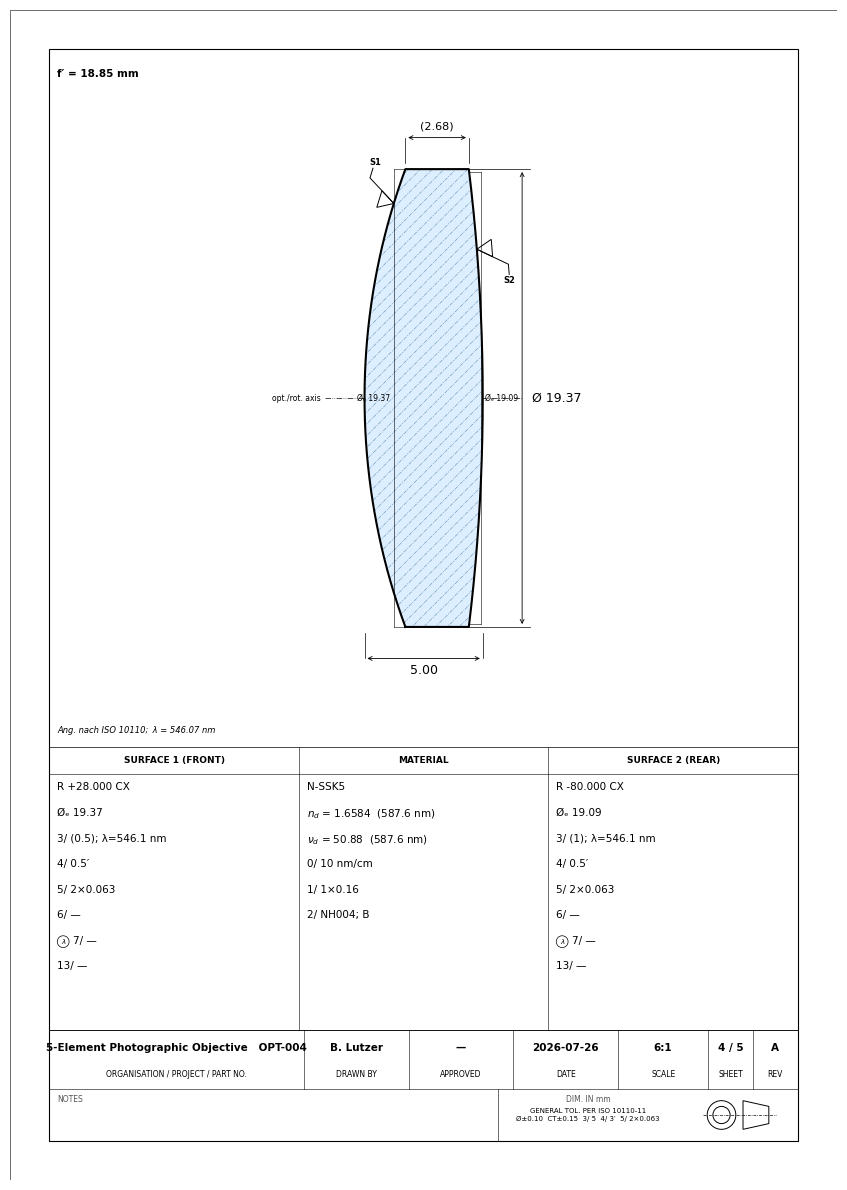

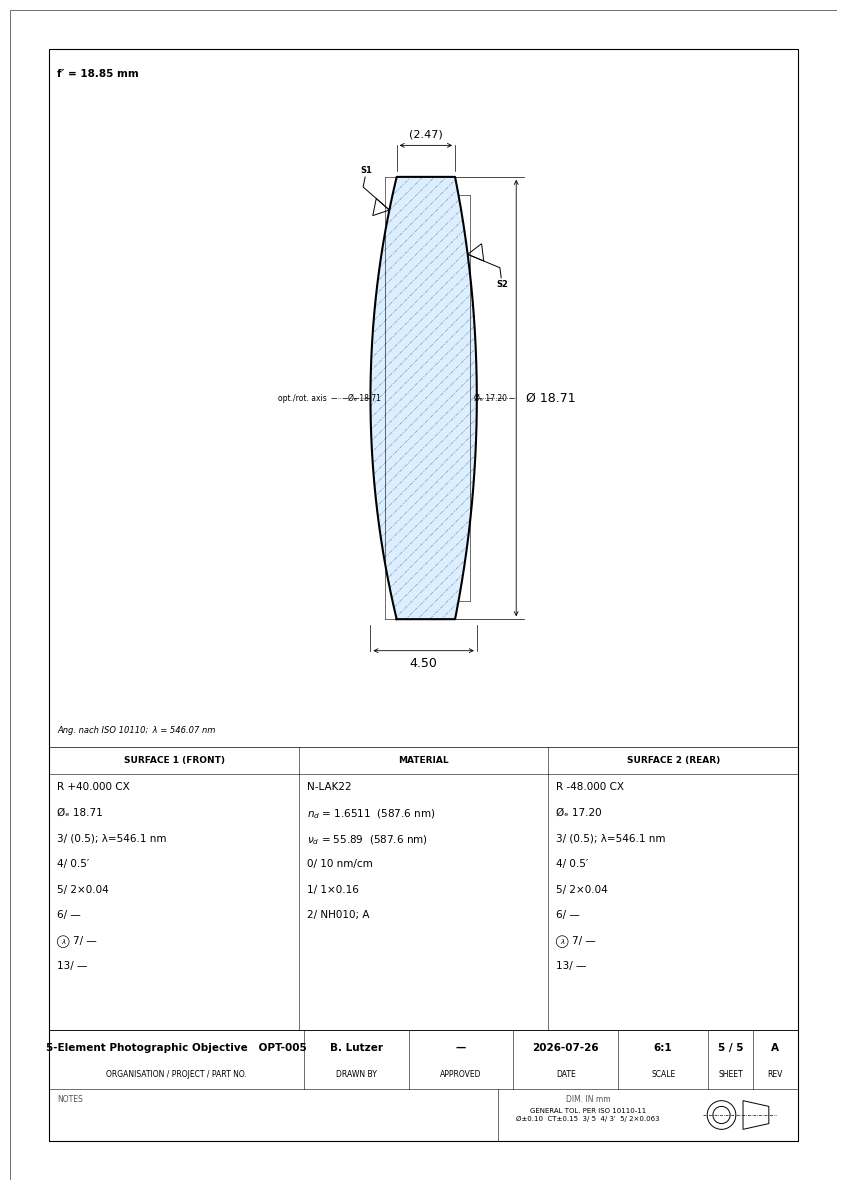

In [12]:
report.show(element_index=3, figsize=(16.5, 11.7))
report.show(element_index=4, figsize=(16.5, 11.7))

## 5. Export to DXF and PDF

### 5.1 Export individual DXF files

Each element gets its own DXF file, named after the project and element number.
These files can be opened in any CAD tool (FreeCAD, QCAD, AutoCAD, etc.) and
integrated into mechanical assembly drawings.

In [13]:
output_dir = Path('iso10110_output')
dxf_paths = report.save_dxf(output_dir)

print('DXF files written:')
for p in dxf_paths:
    print(f'  {p}  ({p.stat().st_size / 1024:.1f} kB)')

DXF files written:
  iso10110_output/5-Element_Photographic_Objective_E01.dxf  (68.8 kB)
  iso10110_output/5-Element_Photographic_Objective_E02.dxf  (68.8 kB)
  iso10110_output/5-Element_Photographic_Objective_E03.dxf  (101.1 kB)
  iso10110_output/5-Element_Photographic_Objective_E04.dxf  (68.8 kB)
  iso10110_output/5-Element_Photographic_Objective_E05.dxf  (68.8 kB)


### 5.2 Export combined multi-page PDF

All five element drawings are combined into a single A3 PDF — ready to
send to the lens manufacturer.

In [14]:
pdf_path = output_dir / '5element_photographic_objective_drawings.pdf'
report.save_pdf(pdf_path, combined=True)
print(f'Combined PDF: {pdf_path}  ({pdf_path.stat().st_size / 1024:.1f} kB)')

Combined PDF: iso10110_output/5element_photographic_objective_drawings.pdf  (121.5 kB)


### 5.3 Export individual PDFs per element

In [15]:
report.save_pdf(output_dir / 'individual', combined=False)
print('Individual PDFs:')
for p in sorted((output_dir / 'individual').glob('*.pdf')):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} kB)')

Individual PDFs:
  5-Element_Photographic_Objective_E01.pdf  (57.3 kB)
  5-Element_Photographic_Objective_E02.pdf  (55.6 kB)
  5-Element_Photographic_Objective_E03.pdf  (68.3 kB)
  5-Element_Photographic_Objective_E04.pdf  (55.5 kB)
  5-Element_Photographic_Objective_E05.pdf  (55.1 kB)


## 6. Working with Individual Drawings

You can also create and customise a single element drawing directly.

In [16]:
from optiland.iso10110 import ElementDrawing

# Grab the cemented doublet (element index 2)
cemented_elem = spec.elements[2]
d = ElementDrawing(cemented_elem, spec, element_index=2)
doc = d.generate()

# Access the raw ezdxf document for custom modifications
msp = doc.modelspace()
print(f'Modelspace entity count: {len(list(msp))}')

# Save standalone
d.save_dxf(output_dir / 'cemented_doublet_OPT003.dxf')
d.save_pdf(output_dir / 'cemented_doublet_OPT003.pdf')
print('Saved standalone cemented doublet drawing.')

Modelspace entity count: 146


Saved standalone cemented doublet drawing.


## 7. Customising Font Sizes and Layout

By default, every drawing uses a fixed set of font sizes and a fixed sheet border
margin. `DrawingStyle` exposes these as named, multiplicative scale factors (plus
an absolute `border_margin` in mm) so they can be adjusted without touching the
renderer source — useful if your printer renders small text faintly, or your
house style prefers a larger spec table.

Every factor defaults to `1.0`, reproducing the built-in appearance exactly; pass
only the fields you want to change. The same `DrawingStyle` instance applies
uniformly to both the PDF/PNG (matplotlib) and DXF output.

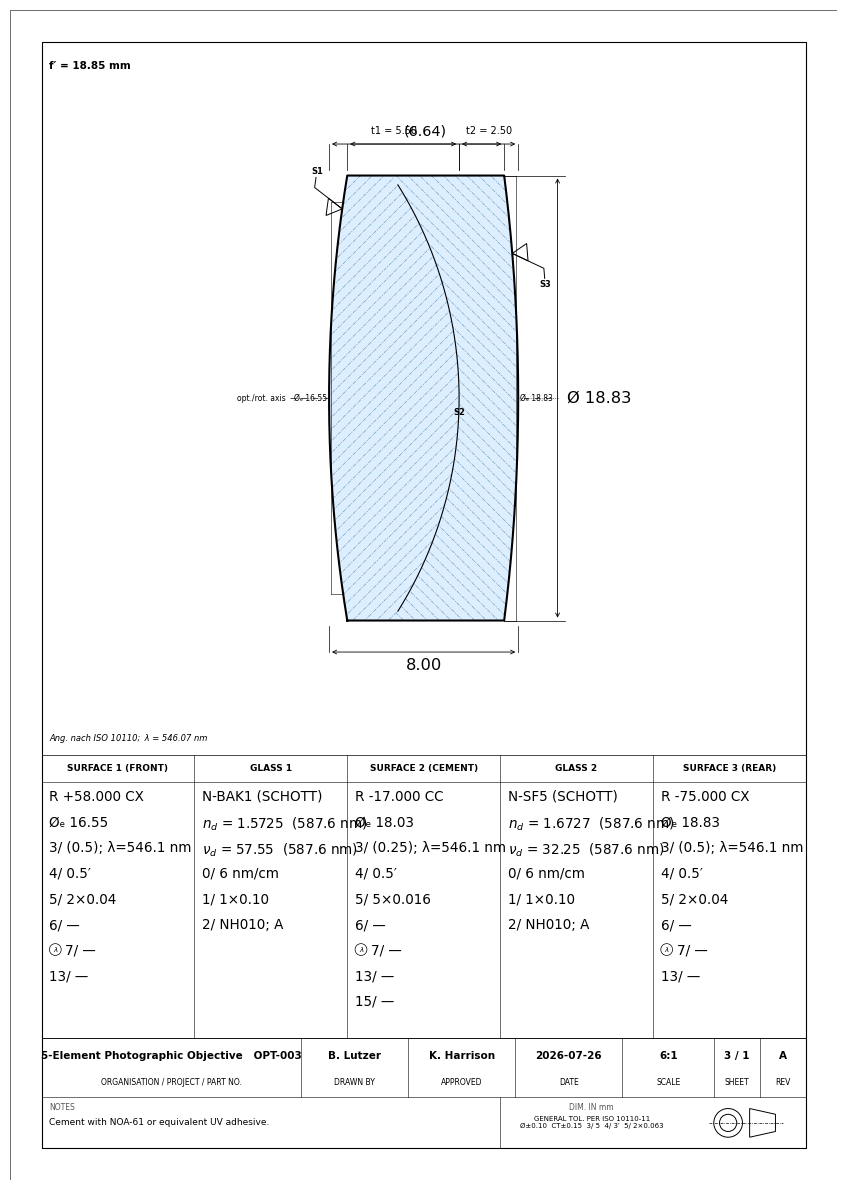

In [17]:
from optiland.iso10110 import DrawingStyle

# Enlarge the spec-table text and the CT/Ø dimension callouts by 30%,
# and shrink the sheet border margin slightly to make room.
custom_style = DrawingStyle(
    table_body_scale=1.3,
    dimension_scale=1.3,
    border_margin=8.0,
)

d_custom = ElementDrawing(cemented_elem, spec, element_index=2, style=custom_style)
d_custom.show(figsize=(16.5, 11.7))

## 8. Summary

The `optiland.iso10110` module provides:

| Component | Role |
|-----------|------|
| `identify_elements(optic)` | Infers singlets / cemented doublets from surface sequence |
| `DrawingSpec` | Annotation overlay: attaches ISO 10110 tolerances to the optic |
| `SurfaceSpec` | Per-surface: form error `3/`, centration `4/`, imperfections `5/` |
| `ElementSpec` | Per-element: birefringence `0/`, bubbles `1/`, homogeneity `2/`, title block info |
| `DrawingSpec.set_element()` | Sets the ISO 10110 optical-quality fields of `ElementSpec` |
| `DrawingSpec.set_title()` | Sets the title-block fields of `ElementSpec` (part number, revision, drawn/approved by, notes) separately from quality specs |
| `DrawingStyle` | Font-size scale factors and border margin for both renderers (see §7) |
| `ElementDrawing` | Single-element DXF drawing (ezdxf backend) |
| `ISO10110Report` | Batches all elements → DXF files + multi-page PDF |

**Output formats:**
- **DXF** — opens in FreeCAD, QCAD, AutoCAD; can be embedded in mechanical assembly drawings
- **PDF** — rendered via ezdxf's matplotlib backend; suitable for documentation and sign-off

**Workflow comparison with Zemax OpticStudio:**
- Zemax stores tolerances per-element in the *ISO Element Drawing* dialog (Codes 3–6 tabs + Material tab)
- optiland stores the same information in `DrawingSpec`, which can be serialised to YAML for hand-off
- Both approaches produce per-element drawings; optiland additionally supports batch PDF generation
  and proper DXF export suitable for mechanical CAD integration